## 2D spectrum

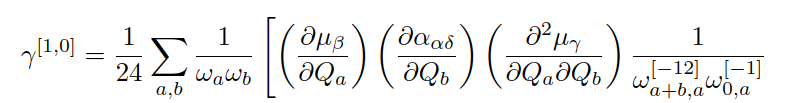

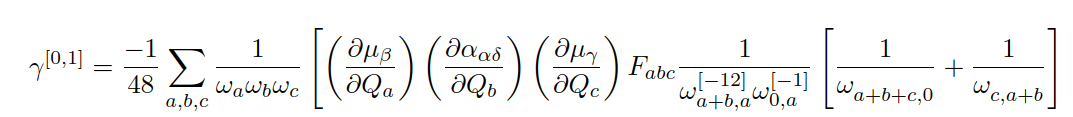

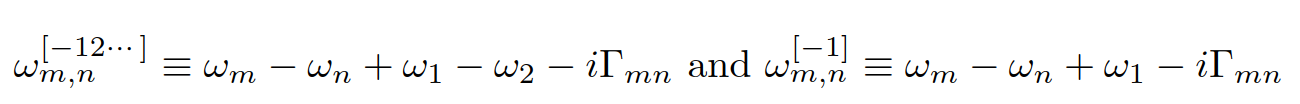

1. Input data for derivs (structure)
2. Orientational averiging
3. Countour plots for spectrum
4. Realistic values of freqs

### VeloxChem calculations

In [49]:
import veloxchem as vlx
import numpy as np
import sys
# import py3Dmol as p3d
from veloxchem.veloxchemlib import bohr_in_angstroms

# Define the molecule and basis set
molecule_string = """3

  O 0.000 0.000  0.000
  H 0.000 0.000  0.950
  H 0.896 0.000 -0.317"""
basis_set_label = 'sto-3g'

molecule = vlx.Molecule.from_xyz_string(molecule_string)
basis = vlx.MolecularBasis.read(molecule, basis_set_label)

# Run the SCF calculation
scf_settings = {}
method_settings = {} #{'xcfun':'b3lyp'}
scf_drv = vlx.ScfRestrictedDriver()
scf_drv.update_settings(scf_settings, method_settings)
scf_results = scf_drv.compute(molecule, basis)

# Create the Hessian Driver and use it to compute an analytical SCF Hessian
hessian_settings = {}
hessian_drv = vlx.scfhessiandriver.ScfHessianDriver(scf_drv)
hessian_drv.update_settings(method_settings, hessian_settings)
hessian_drv.compute(molecule, basis)

hessian_drv.vibrational_analysis(molecule)

* Info * Reading basis set from file: /home/vlew/miniconda3/envs/vlxsthlm/lib/python3.9/site-packages/veloxchem/basis/STO-3G
                                                                                                                          
                                              Molecular Basis (Atomic Basis)                                              
                                                                                                                          
                               Basis: STO-3G                                                                              
                                                                                                                          
                               Atom Contracted GTOs           Primitive GTOs                                              
                                                                                                                          
              

In [71]:
help(hessian_drv)

Help on ScfHessianDriver in module veloxchem.scfhessiandriver object:

class ScfHessianDriver(veloxchem.hessiandriver.HessianDriver)
 |  ScfHessianDriver(scf_drv, comm=None, ostream=None)
 |  
 |  Implements SCF Hessian driver.
 |  
 |  :param scf_drv:
 |      The SCF driver.
 |  :param comm:
 |      The MPI communicator.
 |  :param ostream:
 |      The output stream.
 |  
 |  Instance variables
 |      - scf_drv: The SCF driver.
 |      - do_raman: Additionally calculate Raman intensities
 |              (at significantly higher computational cost).
 |  
 |  Method resolution order:
 |      ScfHessianDriver
 |      veloxchem.hessiandriver.HessianDriver
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, scf_drv, comm=None, ostream=None)
 |      Initializes SCF Hessian driver.
 |  
 |  compute(self, molecule, ao_basis, min_basis=None)
 |      Computes the analytical or numerical nuclear Hessian.
 |      
 |      :param molecule:
 |          The molecule.
 |  

In [3]:
freqs,ints = hessian_drv.frequencies, hessian_drv.ir_intensities
nmodes = hessian_drv.normal_modes
print(freqs)
# print()

[1927.08382347 4545.77721188 4896.43798171]


## 2D-IR intensities

In [87]:
# w1, w1-w2
import math
import numpy as np
import matplotlib.pyplot as plt

# deriv_mu_first[0, i] --- delta(mu_x)/delta(Q_i)
# deriv_mu_first[1, i] --- delta(mu_y)/delta(Q_i)
deriv_mu_first = np.array([
    np.array([0.1, 0.1, 0.]), 
    np.array([0.1, 0.7, 0.1]), 
    np.array([0., 0.1, 0.9])
])

# deriv_mu_second[0, i, j] --- delta(mu_x)/delta(Q_i)/delta(Q_j)
# deriv_mu_second[1, i, j] --- delta(mu_y)/delta(Q_i)/delta(Q_j)
deriv_mu_second = np.array([
    np.array([
        np.array([0.1, 0.1, 0.]), 
        np.array([0.1, 0.1, 0.1]), 
        np.array([0., 0.1, 0.1])
    ]), 
    
    np.array([
        np.array([0.1, 0.1, 0.]), 
        np.array([0.1, -0.1, -0.1]), 
        np.array([0., -0.1, 0.1])
    ]),
    
    np.array([
        np.array([0.1, 0.1, 0.]), 
        np.array([0.1, -0.1, 0.1]), 
        np.array([0., 0.1, 0.9])
    ])
])

deriv_mu = [deriv_mu_first, deriv_mu_second]

# deriv_alpha_first[0, 1, i] --- delta(alpha_xy)/delta(Q_i)
deriv_alpha_first = np.array([
    np.array([
        np.array([9.1, 0.1, 0.]), 
        np.array([0.1, 3.1, 0.1]), 
        np.array([0., 0.1, 4.1])
    ]), 
    
    np.array([
        np.array([9.1, 0.1, 0.]), 
        np.array([0.1, 0.1, 0.1]), 
        np.array([0., 0.1, 4.1])
    ]),
    
    np.array([
        np.array([9.1, 0.1, 0.]), 
        np.array([0.1, 9.1, 0.1]), 
        np.array([0., 0.1, 5.9])
    ])
])

# deriv_alpha_first[0, 1, i] --- delta(alpha_xy)/delta(Q_i)
# deriv_alpha_second[0, 1, i, j] --- delta(alpha_xy)/delta(Q_i)/delta(Q_j)

deriv_alpha_second = np.array([
            np.array([
                np.array([
                    np.array([9.1, 0.1, 0.]), 
                    np.array([0.1, 3.1, 0.1]), 
                    np.array([0., 0.1, 4.1])
                ]), 

                np.array([
                    np.array([9.1, 0.1, 0.]), 
                    np.array([0.1, 3.1, 0.1]), 
                    np.array([0., 0.1, 4.1])
                ]),

                np.array([
                    np.array([9.1, 0.1, 0.]), 
                    np.array([0.1, 9.1, 0.1]), 
                    np.array([0., 0.1, 5.9])
                ])
        ]), 
            np.array([
                np.array([
                    np.array([9.1, 0.1, 0.]), 
                    np.array([0.1, 3.1, 0.1]), 
                    np.array([0., 0.1, 4.1])
                ]), 

                np.array([
                    np.array([9.1, 0.1, 0.]), 
                    np.array([0.1, 3.1, 0.1]), 
                    np.array([0., 0.1, 4.1])
                ]),

                np.array([
                    np.array([9.1, 0.1, 0.]), 
                    np.array([0.1, 9.1, 0.1]), 
                    np.array([0., 0.1, 5.9])
                ])
        ]), 
            np.array([
                np.array([
                    np.array([9.1, 0.1, 0.]), 
                    np.array([0.1, 3.1, 0.1]), 
                    np.array([0., 0.1, 4.1])
                ]), 

                np.array([
                    np.array([9.1, 0.1, 0.]), 
                    np.array([0.1, 3.1, 0.1]), 
                    np.array([0., 0.1, 4.1])
                ]),

                np.array([
                    np.array([9.1, 0.1, 0.]), 
                    np.array([0.1, 9.1, 0.1]), 
                    np.array([0., 0.1, 5.9])
                ])
        ])

])

deriv_alpha = [deriv_alpha_first, deriv_alpha_second]

# w = {0: 1600, 1: 1850, 2: 2200}
w = {0: 1927.08382347, 1: 4545.77721188, 2: 4896.43798171}
combs = {}

Gamma = 0.01
Delta_ab = 80
delta_bc = 50
Delta_abc = 70
Delta_aa = 20
Delta_bb = 10


F = np.zeros((len(w), len(w), len(w)))
F[0, 1, 2] = -0.8


# electrical anharmonicity
# @np.vectorize
def el_anh(w1, w2, deriv_mu, deriv_alpha, Gamma, w, delta_ab):
    """
    a, b, c - normal modes indices as strings
    w - dictionary of normal modes freqs, including som
    e combination bands and overtones
        k:v '(str index or str combination)': freq
    w1 - range of w1 axis values
    w2 - range of w2 axis values
    w1mw2 = w1-w2
    deriv_mu, deriv_alpha - 2D arrays
    """
    
    w1mw2 = w1-w2
    w_0 = 0
    
    totalres = np.zeros((len(w1), len(w2)), dtype='complex128')
    
    suscept_tensor_comp = [[2], [2], [2], [2]]
    
    for a in range(3):
        for b in range(3):
            # print(a, b)
            firstfrac = 1/ w[a] / w[b]
            
            # averaging
            ders_avrg = 0
            count_avrg = 0
            for alpha in suscept_tensor_comp[0]:
                for beta in suscept_tensor_comp[1]:
                    for gamma in suscept_tensor_comp[2]:
                        for delta in suscept_tensor_comp[3]:
                            # print(alpha, beta, gamma, delta, a, b)
                            ders_avrg += deriv_mu[0][beta, a] * deriv_alpha[0][alpha, delta, b] * deriv_mu[1][gamma, a, b]
                            count_avrg += 1
            # print(ders_avrg)
            resonance1_1 = (w[a] + w[b] - Delta_ab) - w[a] - w1mw2 - Gamma * 1j
            resonance2_1 = w_0 - w[a] + w1 - Gamma * 1j
            # avrgders = ders_avrg/count_avrg
            avrgders = 0.01
            term1 = avrgders / resonance1_1 / resonance2_1
            
            # averaging
            ders_avrg2 = 0
            count_avrg2 = 0
            for alpha in suscept_tensor_comp[0]:
                for beta in suscept_tensor_comp[1]:
                    for gamma in suscept_tensor_comp[2]:
                        for delta in suscept_tensor_comp[3]:
                            # print(alpha, beta, gamma, delta, a, b)
                            ders_avrg2 += deriv_mu[0][beta, a] * deriv_alpha[1][alpha, delta, a, b] * deriv_mu[0][gamma, b]
                            count_avrg2 += 1
                            
            resonance1_2 = w[b] - w[a] - w1mw2 - Gamma * 1j
            resonance2_2 = w_0 - w[a] + w1 - Gamma * 1j
            
            term2 = (ders_avrg2/count_avrg2) / resonance1_2 / resonance2_2
            
            totalres += firstfrac * (term1
                                    # +term2
                                    )
    # print(totalres)
    return totalres/24. #* 10**5


def mech_anh(w1, w2, deriv_mu, deriv_alpha, Gamma, F, w, delta_ab, delta_abc):
    w1mw2 = w1-w2
    w_0 = 0

    totalres = np.zeros((len(w1), len(w2)), dtype='complex128')
    
    suscept_tensor_comp = [[2], [2], [2], [2]]
    print(w)
    for a in range(3):
        for b in range(3):
            firstfrac = 1 / w[a] / w[b] / w[c]
            
            fracs = 1 / ((w[a] + w[b] + w[c] - delta_abc) - w_0) + 1 / (w[c] - (w[a] + w[b] - delta_ab))
            
            # averaging
            ders_avrg = 0
            count_avrg = 0
            for alpha in suscept_tensor_comp[0]:
                for beta in suscept_tensor_comp[1]:
                    for gamma in suscept_tensor_comp[2]:
                        for delta in suscept_tensor_comp[3]:
                            # print(alpha, beta, gamma, delta, a, b)
                            ders_avrg += deriv_mu[0][beta, a] * deriv_alpha[0][alpha, delta, b] * deriv_mu[0][gamma, c]
                            count_avrg += 1
            # derivs1 = deriv_mu[a, a] * deriv_alpha[b, b] * deriv_mu[c, c] 
            # print(ders_avrg)
            
            resonance1_1 = (w[a] + w[b] - delta_ab) - w[a] - w1mw2 - Gamma * 1j
            resonance2_1 = w_0 - w[a] - Gamma * 1j
            
            term1 = (ders_avrg/count_avrg) * fracs * F[a, b, c] / resonance1_1 / resonance2_1
            
            fracs2 = 1 / ((w[a] + w[b] - delta_ab) - w[c]) + 1 / ((w[b] + w[c] - delta_bc) - w[a])
            # averaging
            ders_avrg2 = 0
            count_avrg2 = 0
            for alpha in suscept_tensor_comp[0]:
                for beta in suscept_tensor_comp[1]:
                    for gamma in suscept_tensor_comp[2]:
                        for delta in suscept_tensor_comp[3]:
                            # print(alpha, beta, gamma, delta, a, b)
                            ders_avrg2 += deriv_mu[0][beta, a] * deriv_alpha[0][alpha, delta, b] * deriv_mu[0][gamma, c]
                            count_avrg2 += 1
            
            resonance1_2 = w[c] - w[a] - w1mw2 - Gamma * 1j
            resonance2_2 = w_0 - w[a] - Gamma * 1j
            
            term2 = (ders_avrg2/count_avrg2) * fracs2 * F[a, b, c] / resonance1_2 / resonance2_2
            
            
            fracs3 = 1 / (w[a] - (w[a] + w[b] - delta_ab)) + 1 / (w[b] - w_0)
            # averaging
            ders_avrg3 = 0
            count_avrg3 = 0
            for alpha in suscept_tensor_comp[0]:
                for beta in suscept_tensor_comp[1]:
                    for gamma in suscept_tensor_comp[2]:
                        for delta in suscept_tensor_comp[3]:
                            # print(alpha, beta, gamma, delta, a, b)
                            ders_avrg3 += deriv_mu[0][beta, a] * deriv_alpha[0][alpha, delta, b] * deriv_mu[0][gamma, a]
                            count_avrg3 += 1
            
            resonance1_3 = (w[a] + w[b] - delta_ab) - w[a] - w1mw2 - Gamma * 1j
            resonance2_3 = w_0 - w[a] - Gamma * 1j
            
            term3 = (ders_avrg3/count_avrg3) * fracs3 * F[a, b, c] / resonance1_3 / resonance2_3
            totalres += firstfrac * (term1 
                                     # + term2
                                     # + term3
                                    )
    
    return -totalres/48. #* 10**5

w1 = np.array([1997., 4355., 4900.])
w2 = np.array([1997., 4355., 4900.])
xx, yy = np.meshgrid(w1, w2)

# xx, yy = np.array([1597.]), np.array([1697.])

z = (el_anh(xx, yy, deriv_mu, deriv_alpha, Gamma, w, Delta_ab) + mech_anh(xx, yy, deriv_mu, deriv_alpha, Gamma, F, w, Delta_ab, Delta_abc))**2 * 10**25
np.set_printoptions(suppress=True)
print(z)

   
def spectrum(w1, w2, w, F, delta_ab, option1=False, prt=False):
    # print(w)
    if option1:
        X, Y = np.meshgrid(w1, w1-w2)
    else:
        X, Y = np.meshgrid(w1, w2)
    
    # print(type(el_anh(X, Y, deriv_mu, deriv_alpha, Gamma, w, delta_ab)))
    # print(type(mech_anh(X, Y, deriv_mu, deriv_alpha, Gamma, F, w, delta_ab, delta_abc)))
    
    # compute the third dimension at each point on the grid
    Z = abs(el_anh(X, Y, deriv_mu, deriv_alpha, Gamma, w, delta_ab) 
            # + mech_anh(X, Y, deriv_mu, deriv_alpha, Gamma, F, w, delta_ab, delta_abc)
           )**2 #* 10**21
    
    
    # Z = el_anh(X, Y)**2
    print(Z) if prt else None

    for k, v in w.items():
        print(k, v) if prt else None
        
    return X, Y, Z

{0: 1927.08382347, 1: 4545.77721188, 2: 4896.43798171}
[[(1.2722470459428912e-05+3.837318124667641e-09j)
  (2.064219449975439e-06-3.173827569154668e-10j)
  (0.00034909962501235346+1.9160323854383633e-06j)]
 [(3.106140291543558e-06+9.210351185013966e-10j)
  (4.177852563965186e-07-3.94845696953568e-11j)
  (0.0014810493581318782+8.22251079245561e-06j)]
 [(2.511663718480449e-06+7.436292881189053e-10j)
  (2.688998352480624e-07-2.5978125189978872e-11j)
  (0.0008144701818851881+4.518553922967136e-06j)]]


[[1900.         1900.         1900.         ... 1900.
  1900.         1900.        ]
 [1934.71910112 1934.71910112 1934.71910112 ... 1934.71910112
  1934.71910112 1934.71910112]
 [1969.43820225 1969.43820225 1969.43820225 ... 1969.43820225
  1969.43820225 1969.43820225]
 ...
 [4920.56179775 4920.56179775 4920.56179775 ... 4920.56179775
  4920.56179775 4920.56179775]
 [4955.28089888 4955.28089888 4955.28089888 ... 4955.28089888
  4955.28089888 4955.28089888]
 [4990.         4990.         4990.         ... 4990.
  4990.         4990.        ]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


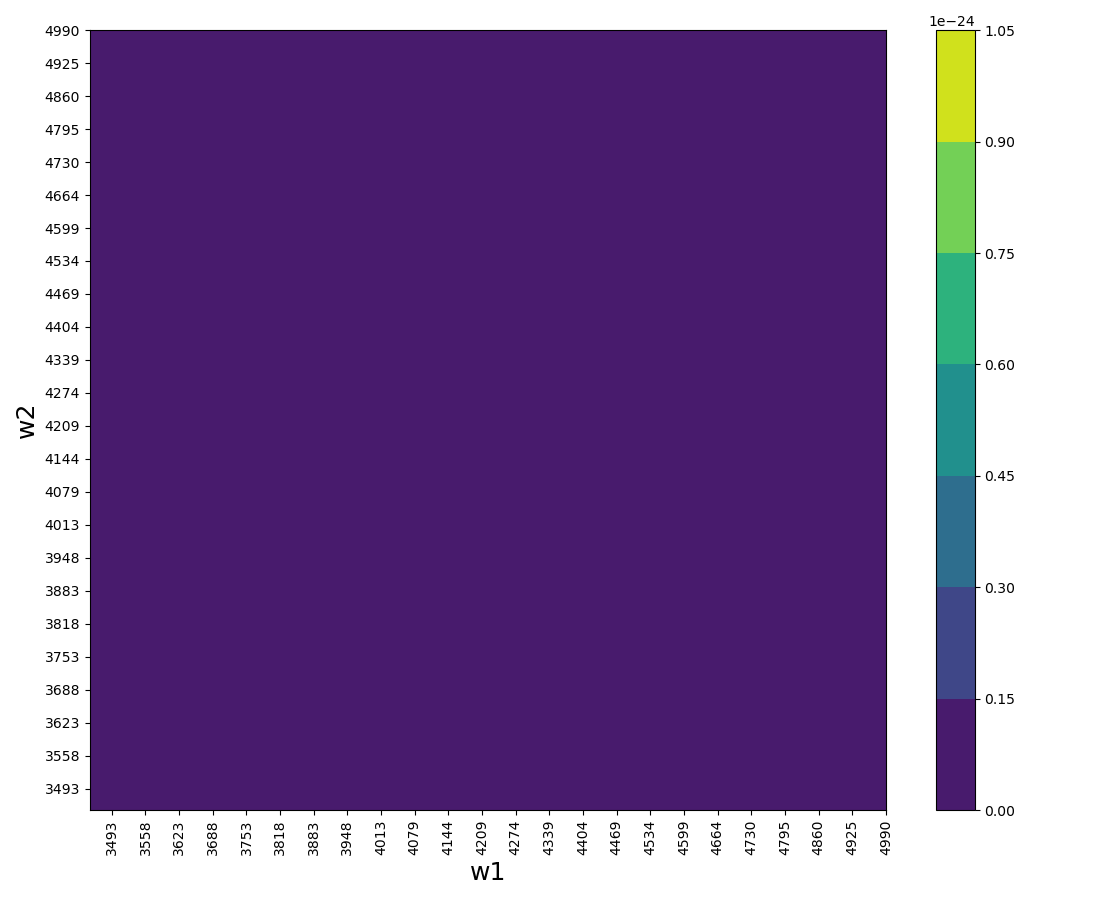

In [88]:
%matplotlib widget
from ipywidgets import *
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm


# w2 = np.array([ 2, 5, 8, 10, 13])
# w1 = np.array([ 2, 5, 8, 10, 13])

# w2 = np.array([ 5, 8, 13])
# w1 = np.array([ 5, 8, 13])

# w2 = np.linspace(2, 13, 10)
# w1 = np.linspace(2, 13, 10)

w1, w2 = np.linspace(1900, 4990, 90), np.linspace(1900, 4990, 90)

# w = {0: 3,
#      1: 7, 
#      2: 11}
# w = {0: 1180, 1: 2170, 2: 3160}

w = {0: 1927.08382347, 1: 4545.77721188, 2: 4896.43798171}
# w = {0: 1927.08382347, 1: 3300, 2: 4545.77721188, 3: 4896.43798171}
# w1 = np.array([1997., 4355., 4900.])
# w2 = np.array([1997., 4355., 4900.])


F = np.zeros((len(w), len(w), len(w)))
F[0, 1, 2] = 0.24

Gamma = 0.00001
delta_ab = 5
delta_abc = 30
delta_aa = 1
delta_bb = 1

option1 = False

# x = np.linspace(0, 2 * np.pi)
# fig = plt.figure()
# ax = fig.add_subplot(1, 1, 1)
# line, = ax.plot(x, np.sin(x))

# plt.ion()

fig, ax = plt.subplots()
fig.set_size_inches(11, 9)

X, Y, Z = spectrum(w1, w2, w, F, delta_ab, option1=option1, prt=False)

# print(len(X.flatten()), len(Y.flatten()), len(Z.flatten()))
# sc = ax.scatter(X.flatten(), Y.flatten(), c=Z.flatten(), cmap='viridis', s=200)
# print(Z)
cp = ax.contourf(X, Y, Z)

# for i in w:
#     ax.axhline(y=w[i], color='r', linestyle='-', label=f'w_{i}')
#     ax.axvline(x=w[i], color='r', linestyle='-', label=f'w_{i}')
    
#     ax.text(w[i]-0.2, -0.5, 
#                 f'w_{i}',
#                 #f'({X[i, j]:.2f}, {Y[i, j]:.2f}, {Z[i, j]:.2f})',
#                 ha='right', va='bottom')

ax.set_xlabel('w1', fontsize=18)


if option1:
    ax.set_ylabel('w1-w2', fontsize=18)
else:
    ax.set_ylabel('w2', fontsize=18)

# ax.legend()

cb = plt.colorbar(cp)
# plt.grid()
fig.set_tight_layout(True)
# set the tick frequency on x and y axis
ax.set_xticks(np.linspace(1800., 4990, 50))
ax.set_yticks(np.linspace(1800., 4990, 50))
ax.set_xlim(3450, 4990)
ax.set_ylim(3450, 4990)

# ax.set_ylim(-10, 100)
# ax.set_yticks(np.linspace(-10., 100, 12))

plt.xticks(rotation = 90) # Rotates X-Axis Ticks by 90-degree

# for i in range(len(w1)):
#     for j in range(len(w2)):
#         ax.text(X[i, j]-0.2, Y[i, j]+0.3, 
#                 f'{Z[i, j]:.3f}',
#                 #f'({X[i, j]:.2f}, {Y[i, j]:.2f}, {Z[i, j]:.2f})',
#                 ha='right', va='bottom')

plt.show()

In [2]:
# w2 = np.array([ 2, 3, 5])
# w1 = np.array([ 2, 3, 5])

# w = {0: 1,
#      1: 4, 
#      2: 6}

# F = np.zeros((len(w), len(w), len(w)))
# F[0, 1, 2] = 0.01

# %matplotlib widget
# # spectrum(w1, w2, w, F, option1=False, prt=True)
# # spectrum(w1, w2, w, F, option1=True)

In [ ]:
lines = {}
        
def update(Fabc
          # , nu0, nu1, nu2, delta_ab
          ):
    global cb
    F[0, 1, 2] = Fabc
    # w[0] = nu0
    # w[1] = nu1
    # w[2] = nu2
    
    Xp, Yp, Zp = spectrum(w1, w2, w, F, delta_ab, option1=option1, prt=False)

    # sc = ax.scatter(Xp.flatten(), Yp.flatten(), c=Zp.flatten(), cmap='viridis'
    #                 #, s=20
    #                )
    
    cp = ax.contour(Xp, Yp, Zp)
    
    # sc.set_offsets(np.c_[Xp,Yp])
    # sc.set_array(Zp.flatten()) 

    # for text in ax.texts:
    #     if text.get_text() != '':  # only remove ax.text objects
    #         text.remove()
            
    # for i in range(len(w1)):
    #     for j in range(len(w2)):
    #         ax.text(Xp[i, j]-0.2, Yp[i, j]+0.3, 
    #                 f'{Zp[i, j]:.3f}',
    #                 #f'({X[i, j]:.2f}, {Y[i, j]:.2f}, {Z[i, j]:.2f})',
    #                 ha='right', va='bottom')
    
    color = iter(cm.rainbow(np.linspace(0, 1, len(w)))) 
    # for i in w:
    
    if not lines == {}:
        for i, c in zip(range(len(w)), color):
        
            # print(lines)
            lines.pop(i).remove()
            lines.pop(i+10).remove()
    
    for i, c in zip(range(len(w)), color):
        # color = next(color)
        # print(lines, 'hdkweh')

        lines[i] = ax.axhline(y=w[i], color=c, linestyle='-', label=f'w_{i}')
        lines[i+10] = ax.axvline(x=w[i], color=c, linestyle='-', label=f'w_{i}')
        # print(lines, 'after')

        # ax.text(w[i]-0.2, -0.5, 
        #             f'w_{i}',
        #             #f'({X[i, j]:.2f}, {Y[i, j]:.2f}, {Z[i, j]:.2f})',
        #             ha='right', va='bottom')
        
    # print(list(ax.lines))
    # print(lines)
    cb.remove()   # FIX updating colorbar
    cb = plt.colorbar(cp)
    fig.canvas.draw_idle()

    # print(Z)

# Fabc_slider = FloatSlider(min=0.1, max=6, step=0.1, value=0.1)
# nu0_slider = FloatSlider(min=1, max=5, step=0.5, value=2)
# nu1_slider = FloatSlider(min=4, max=9, step=0.5, value=6)
# nu2_slider = FloatSlider(min=9, max=13, step=0.5, value=10)

# delta_ab_slider = FloatSlider(min=50., max=200., step=10, value=50.0)

# interact(update, Fabc=Fabc_slider, 
#          #nu0=nu0_slider, nu1=nu1_slider, nu2=nu2_slider, delta_ab=delta_ab_slider, 
#          sc=sc) # FIX sc thing
plt.show()

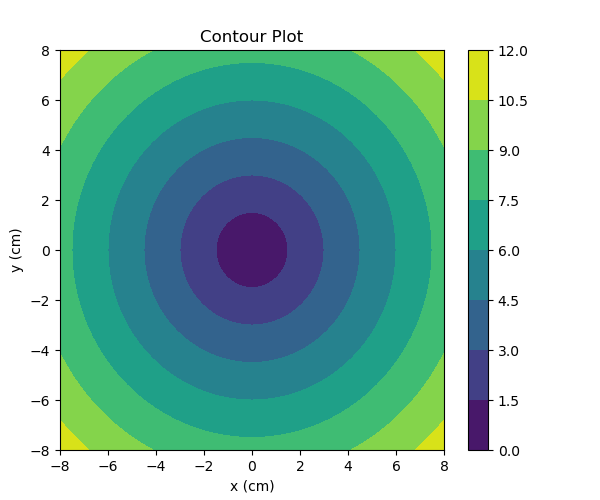

In [46]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(6,5))
left, bottom, width, height = 0.1, 0.1, 0.8, 0.8
ax = fig.add_axes([left, bottom, width, height]) 

start, stop, n_values = -8, 8, 800

x_vals = np.linspace(start, stop, n_values)
y_vals = np.linspace(start, stop, n_values)
X, Y = np.meshgrid(x_vals, y_vals)


Z = np.sqrt(X**2 + Y**2)

cp = plt.contourf(X, Y, Z)
plt.colorbar(cp)

ax.set_title('Contour Plot')
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
plt.show()

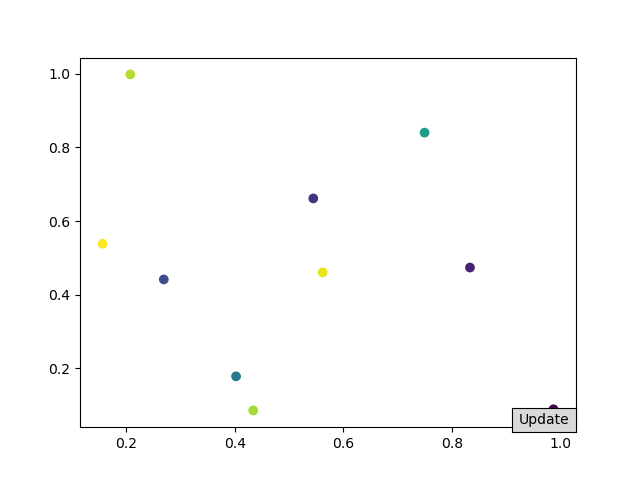

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# generate some initial data
x = np.random.rand(10)
y = np.random.rand(10)
colors = np.random.rand(10)

# create a scatter plot of the data
fig, ax = plt.subplots()
sc = ax.scatter(x, y, c=colors)

# define a function to update the data
def update_data():
    new_x = np.random.rand(10)
    new_y = np.random.rand(10)
    new_colors = np.random.rand(10)
    sc.set_offsets(np.c_[new_x, new_y])
    sc.set_array(new_colors)
    fig.canvas.draw()

# connect the function to a button click event
button_ax = fig.add_axes([0.8, 0.1, 0.1, 0.05])
button = plt.Button(button_ax, 'Update')
button.on_clicked(lambda event: update_data())

# show the plot
plt.show()


### Saved images

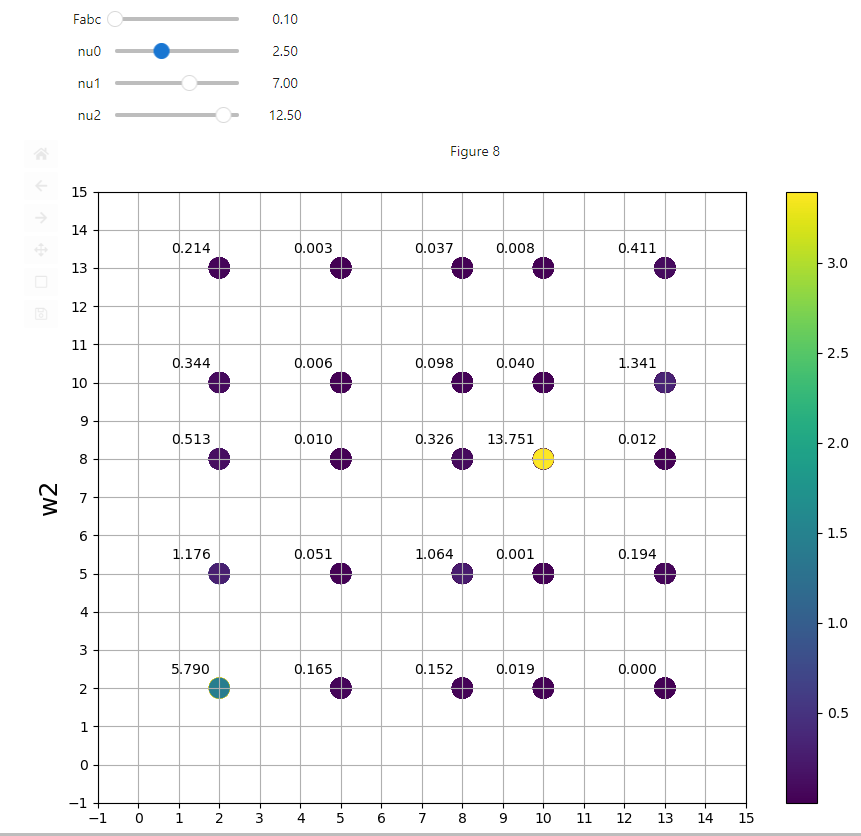

-----
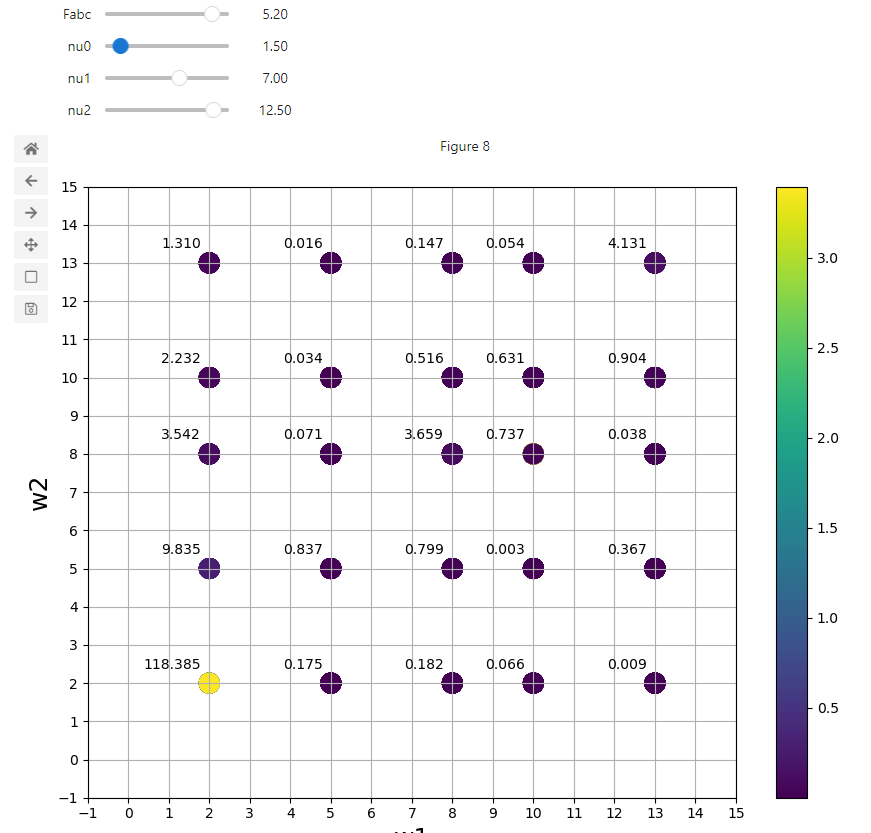